# Librerías

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from urllib.request import urlopen
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Conjunto de datos

Total imágenes: 50


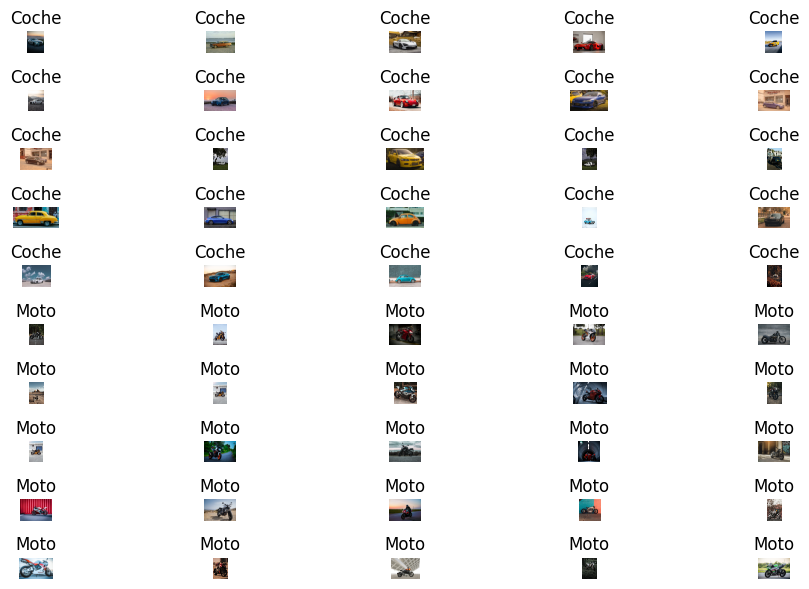

In [12]:
np.random.seed(42)

# (puede cambiar/añadir)
coches = [
    "https://images.unsplash.com/photo-1580273916550-e323be2ae537?q=80&w=764&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1664303847960-586318f59035?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MXx8Y29jaGVzfGVufDB8fDB8fHww",
    "https://images.unsplash.com/photo-1542362567-b07e54358753?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8N3x8Y29jaGVzfGVufDB8fDB8fHww",
    "https://images.unsplash.com/photo-1583121274602-3e2820c69888?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTB8fGNvY2hlc3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1605559424843-9e4c228bf1c2?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTV8fGNvY2hlc3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1616422285623-13ff0162193c?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mjd8fGNvY2hlc3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1603386329225-868f9b1ee6c9?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MzF8fGNvY2hlc3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1588258219511-64eb629cb833?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mzh8fGNvY2hlc3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1694102281785-e338b4b2ee1f?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTJ8fGNvY2hlc3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1648153222453-3111189fc709?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NjJ8fGNvY2hlc3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1648153224279-4b125003d5f2?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NzV8fGNvY2hlc3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1725033215378-f13aa2b71422?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTAzfHxjb2NoZXN8ZW58MHx8MHx8fDA%3D",
    "https://images.unsplash.com/photo-1694103224829-58754b9f87b1?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTk4fHxjb2NoZXN8ZW58MHx8MHx8fDA%3D",
    "https://images.unsplash.com/photo-1723590184608-bdcac5fe8f8a?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MjA4fHxjb2NoZXN8ZW58MHx8MHx8fDA%3D",
    "https://images.unsplash.com/photo-1727129250551-19712db439be?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MjI1fHxjb2NoZXN8ZW58MHx8MHx8fDA%3D",
    "https://images.unsplash.com/photo-1459603677915-a62079ffd002?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTl8fGNhcnN8ZW58MHx8MHx8fDA%3D",
    "https://images.unsplash.com/photo-1502877338535-766e1452684a?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTh8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1489824904134-891ab64532f1?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mjd8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1517676109075-9a94d44145d1?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mjh8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1506610654-064fbba4780c?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MzF8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1537984822441-cff330075342?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mzh8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1552519507-da3b142c6e3d?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NDJ8fGNhcnxlbnwwfHwwfHx8MA%3D%3D,"
    "https://images.unsplash.com/photo-1519641471654-76ce0107ad1b?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTJ8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1511125357779-27038c647d9d?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTh8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1532974297617-c0f05fe48bff?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NjN8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1541348263662-e068662d82af?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NzF8fGNhcnxlbnwwfHwwfHx8MA%3D%3D",
]

motos = [
"https://images.unsplash.com/photo-1591637333184-19aa84b3e01f?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8M3x8bW90b3JjeWNsZXxlbnwwfHwwfHx8MA%3D%3D",
"https://images.unsplash.com/photo-1609630875171-b1321377ee65?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8bW90b3JjeWNsZXxlbnwwfHwwfHx8MA%3D%3D",
"https://images.unsplash.com/photo-1568772585407-9361f9bf3a87?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NHx8bW90b3JjeWNsZXxlbnwwfHwwfHx8MA%3D%3D",
"https://images.unsplash.com/photo-1449426468159-d96dbf08f19f?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8OHx8bW90b3JjeWNsZXxlbnwwfHwwfHx8MA%3D%3D",
"https://images.unsplash.com/photo-1558981285-6f0c94958bb6?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MzF8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1582092722992-b2f960bafbfb?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MzJ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1609630875289-22852fa678ce?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MzZ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1572746965401-cb4df8f9fa79?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NDB8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1615172282427-9a57ef2d142e?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mzl8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1635094742897-3f0014ccc07b?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MzR8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1609630875289-22852fa678ce?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MzZ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1591378603223-e15b45a81640?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTB8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1508357941501-0924cf312bbd?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTJ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1615812309036-e3aeba454bba?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTZ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1558981001-5864b3250a69?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NjB8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1619771914272-e3c1ba17ba4d?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTl8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1471466054146-e71bcc0d2bb2?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NjJ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1504160820508-da86e9dc8a28?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NjZ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1570306296747-f7bb428e4fe0?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Nzh8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1617109887854-f661d37fca2d?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8ODJ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1542683088-abb3da334598?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8ODR8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1685164815367-db4f6ff3a638?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8ODZ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1558974804-2c2b396b60df?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8OTJ8fG1vdG9yY3ljbGV8ZW58MHx8MHx8fDA%3D",
"https://images.unsplash.com/photo-1597479434905-db73b8789725?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTA3fHxtb3RvcmN5Y2xlfGVufDB8fDB8fHww",
"https://images.unsplash.com/photo-1580310614729-ccd69652491d?w=500&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTEyfHxtb3RvcmN5Y2xlfGVufDB8fDB8fHww",
    
]

labels = []
images_rgb = []

# Descarga a RGB/Gray
for url in coches + motos:
    img_bytes = urlopen(url).read()
    img_bgr = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    images_rgb.append(img_rgb)
    labels.append("Coche" if url in coches else "Moto")

print("Total imágenes:", len(images_rgb))
plt.figure(figsize=(10,6))

for i in range(len(images_rgb)):
    plt.subplot(10, 5, i+1)
    plt.imshow(images_rgb[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout(); plt.show()

# Extracción de características

Keypoints por imagen: [489, 519, 1279, 455, 615, 908, 412, 1213, 1170, 1520, 576, 2481, 633, 1770, 2842, 699, 648, 614, 801, 2209, 548, 700, 1415, 622, 4070, 1184, 1226, 675, 994, 1128, 2810, 1127, 1760, 628, 3282, 1127, 1454, 819, 340, 1180, 484, 1270, 365, 965, 6685, 1213, 2108, 2520, 2950, 1111]


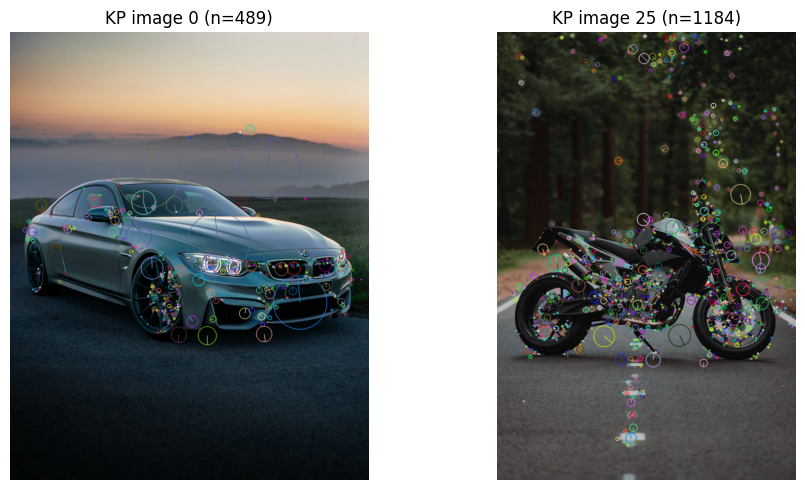

In [13]:
sift = cv2.SIFT_create()

images_gray = []
all_desc_list = []   # Descriptores
n_keypoints = []

for img_rgb in images_rgb:
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    images_gray.append(gray)
    keypoints, descriptors = sift.detectAndCompute(gray, None) # Detecta puntos y calcula descriptores (SIFT = 128D por keypoint)

    if descriptors is None:
        descriptors = np.zeros((0, 128), dtype=np.float32)

    all_desc_list.append(descriptors)
    n_keypoints.append(len(keypoints))

print("Keypoints por imagen:", n_keypoints)


plt.figure(figsize=(10,5)) # Dónde aparece SIFT
for i, idx in enumerate([0, len(images_rgb)//2]):

    img_kp = cv2.drawKeypoints(images_rgb[idx], sift.detect(images_gray[idx], None), None,
                               flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.subplot(1,2,i+1); plt.imshow(img_kp); plt.title(f"KP image {idx} (n={n_keypoints[idx]})"); plt.axis('off')

plt.tight_layout(); plt.show()


# Extractor de carateristicas ORB


Keypoints por imagen (ORB): [500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 462, 495, 499, 500, 500, 500, 500, 493, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


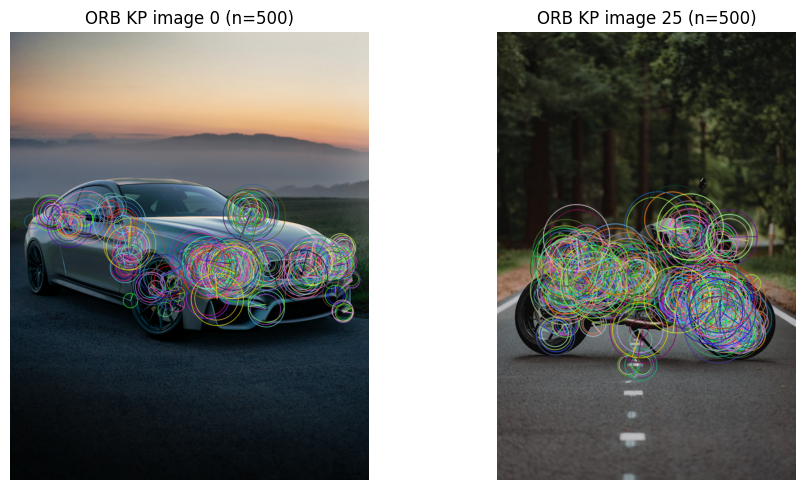

In [17]:
orb = cv2.ORB_create(nfeatures=500)

images_gray_orb = []
all_desc_list_orb = []   # Descriptores ORB
n_keypoints_orb = []

for img_rgb in images_rgb:
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    images_gray_orb.append(gray)
    
    keypoints, descriptors = orb.detectAndCompute(gray, None)

    if descriptors is None:
        descriptors = np.zeros((0, 32), dtype=np.uint8)  # ⚠️ ORB usa 32

    all_desc_list_orb.append(descriptors)
    n_keypoints_orb.append(len(keypoints))

print("Keypoints por imagen (ORB):", n_keypoints_orb)

plt.figure(figsize=(10,5))

for i, idx in enumerate([0, len(images_rgb)//2]):

    img_kp = cv2.drawKeypoints(
        images_rgb[idx],
        orb.detect(images_gray_orb[idx], None),
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    plt.subplot(1,2,i+1)
    plt.imshow(img_kp)
    plt.title(f"ORB KP image {idx} (n={n_keypoints_orb[idx]})")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Construcción de diccionario/vocabulario

In [14]:

desc_stack = [] # Apila descriptores de todas las imágenes en una sola matriz para k-means

for desc in all_desc_list:

    if len(desc) > 400: #  muestreo (máx 400 por imagen)
        idx = np.random.choice(len(desc), 400, replace=False)
        desc = desc[idx]
    desc_stack.append(desc)

if len(desc_stack) == 0:
    raise RuntimeError("No hay descriptores; revisa que SIFT detecte puntos (más imágenes o mayor detalle).")

desc_stack = np.vstack(desc_stack).astype(np.float32)
print("Descriptores totales para k-means:", desc_stack.shape)


K = 80 # Tamaño del vocabulario (ajústalo y experimenta)

kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=2048, n_init="auto") # MiniBatchKMeans es más rápido y estable que KMeans para muchos puntos
kmeans.fit(desc_stack)

centers = kmeans.cluster_centers_
print("Diccionario visual entrenado. Centros shape:", centers.shape)


Descriptores totales para k-means: (19905, 128)
Diccionario visual entrenado. Centros shape: (80, 128)


# Construccion de diccionario para ORB

In [19]:
desc_stack_orb = []  # Apila descriptores ORB

for desc in all_desc_list_orb:

    if len(desc) > 400:  # muestreo (máx 400 por imagen)
        idx = np.random.choice(len(desc), 400, replace=False)
        desc = desc[idx]

    desc_stack_orb.append(desc)

if len(desc_stack_orb) == 0:
    raise RuntimeError("No hay descriptores ORB; revisa que ORB detecte puntos.")

# ⚠️ ORB es uint8 → convertir a float32 para KMeans
desc_stack_orb = np.vstack(desc_stack_orb).astype(np.float32)

print("Descriptores totales ORB para k-means:", desc_stack_orb.shape)


K = 80  

kmeans_orb = MiniBatchKMeans(
    n_clusters=K,
    random_state=42,
    batch_size=2048,
    n_init="auto"
)

kmeans_orb.fit(desc_stack_orb)

centers_orb = kmeans_orb.cluster_centers_

print("Diccionario visual ORB entrenado. Centros shape:", centers_orb.shape)

Descriptores totales ORB para k-means: (20000, 32)
Diccionario visual ORB entrenado. Centros shape: (80, 32)


# Cuantificación vectorial

X (BoVW): (50, 80)  y: (50,)   (K = 80 )


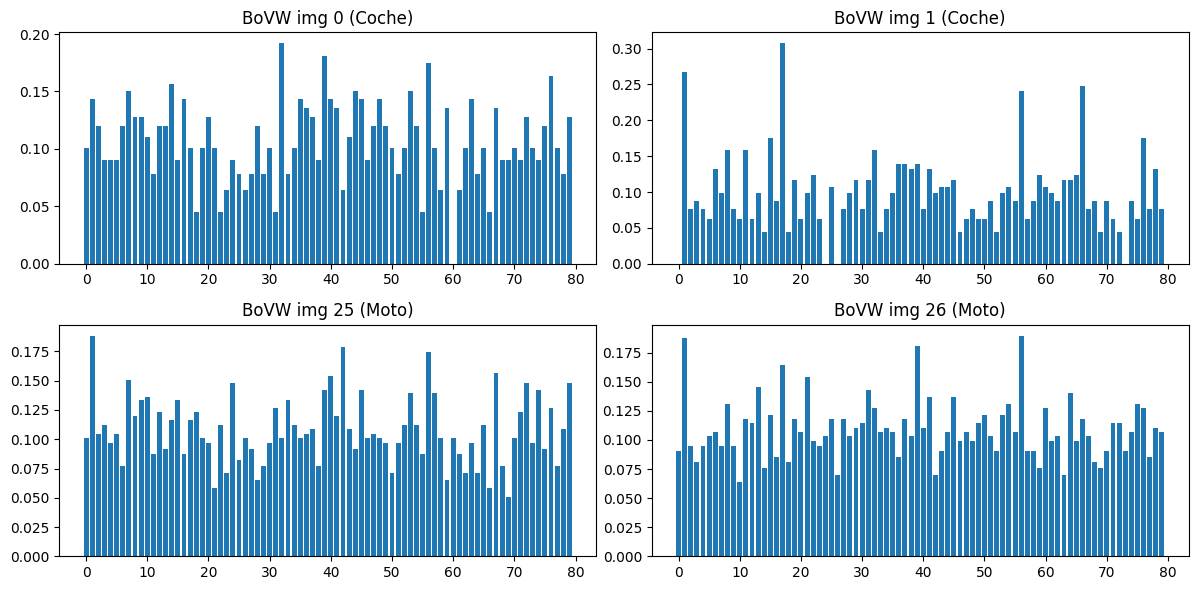

In [22]:
bovw_list = [] # # Codifica cada imagen como histograma BoVW

for i, desc in enumerate(all_desc_list):
    if len(desc) == 0:

        hist = np.zeros(K, dtype=np.float32)
    else:
        # Asignación dura (hard assignment): cada descriptor -> centro más cercano
        # predict() devuelve el índice del cluster para cada descriptor
        word_ids = kmeans.predict(desc)               # shape: (num_desc,)
        hist = np.bincount(word_ids, minlength=K)     # cuentas por palabra visual (0..K-1)
        hist = hist.astype(np.float32)

    # Normalización recomendada (power-law + L2)
    hist = np.sqrt(hist)
    norm = np.linalg.norm(hist) + 1e-8
    hist = hist / norm

    bovw_list.append(hist)

X = np.vstack(bovw_list)             # shape: (num_imagenes, K)
y = np.array(labels)                 # etiquetas: "cat"/"dog"

print("X (BoVW):", X.shape, " y:", y.shape, "  (K =", K, ")")


plt.figure(figsize=(12,6))

indices =[0,1,25,26]  # índices de imágenes para mostrar 

for i, idx in enumerate(indices):
    plt.subplot(2,2,i+1)
    plt.bar(np.arange(K), X[idx])
    plt.title(f"BoVW img {idx} ({y[idx]})")

plt.tight_layout()
plt.show()

# Cuantificacion ORB

X_orb (BoVW): (50, 80)  y: (50,)  (K = 80 )


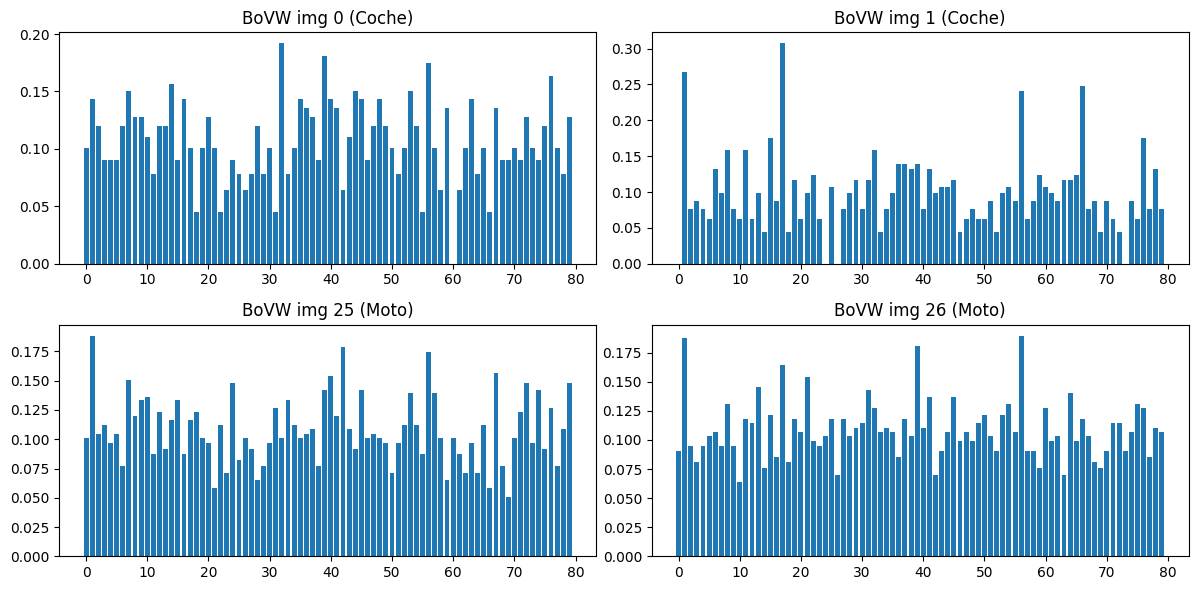

In [21]:
bovw_list_orb = []  # Codifica cada imagen como histograma BoVW (ORB)

for i, desc in enumerate(all_desc_list_orb):
    
    if len(desc) == 0:
        hist = np.zeros(K, dtype=np.float32)
    else:
        # ⚠️ ORB debe estar en float32 para usar KMeans
        desc = desc.astype(np.float32)

        word_ids = kmeans_orb.predict(desc)              # asignación a clusters
        hist = np.bincount(word_ids, minlength=K)        # histograma
        hist = hist.astype(np.float32)

    # Normalización (igual que SIFT → importante para comparar)
    hist = np.sqrt(hist)
    norm = np.linalg.norm(hist) + 1e-8
    hist = hist / norm

    bovw_list_orb.append(hist)

X_orb = np.vstack(bovw_list_orb)   # (num_imagenes, K)
y_orb = np.array(labels)           # mismas etiquetas

print("X_orb (BoVW):", X_orb.shape, " y:", y_orb.shape, " (K =", K, ")")

plt.figure(figsize=(12,6))

indices =[0,1,25,26]  # índices de imágenes para mostrar 

for i, idx in enumerate(indices):
    plt.subplot(2,2,i+1)
    plt.bar(np.arange(K), X[idx])
    plt.title(f"BoVW img {idx} ({y[idx]})")

plt.tight_layout()
plt.show()

# Clasificación (Laboratorio)

Accuracy (SVM lineal): 75.00%

Reporte de clasificación:
               precision    recall  f1-score   support

       Coche       0.78      0.70      0.74        10
        Moto       0.73      0.80      0.76        10

    accuracy                           0.75        20
   macro avg       0.75      0.75      0.75        20
weighted avg       0.75      0.75      0.75        20



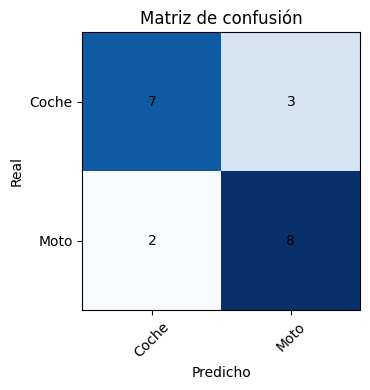

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=42, stratify=y)

clf = LinearSVC(C=1.0, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy (SVM lineal):", f"{acc*100:.2f}%")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

classes = sorted(list(set(y)))
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Blues')
plt.title("Matriz de confusión")
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)    

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.xlabel("Predicho"); plt.ylabel("Real")
plt.tight_layout(); plt.show()


Accuracy (SVM lineal - ORB): 80.00%

Reporte de clasificación (ORB):
               precision    recall  f1-score   support

       Coche       0.80      0.80      0.80        10
        Moto       0.80      0.80      0.80        10

    accuracy                           0.80        20
   macro avg       0.80      0.80      0.80        20
weighted avg       0.80      0.80      0.80        20



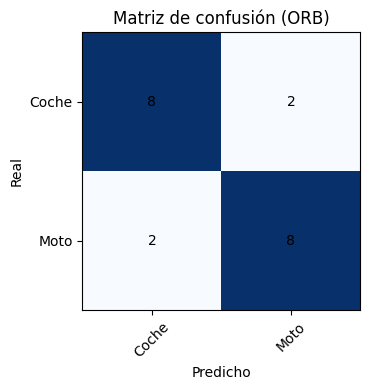

In [25]:
X_train_orb, X_test_orb, y_train_orb, y_test_orb = train_test_split(
    X_orb, y_orb, test_size=0.40, random_state=42, stratify=y_orb
)

clf_orb = LinearSVC(C=1.0, random_state=42)
clf_orb.fit(X_train_orb, y_train_orb)

y_pred_orb = clf_orb.predict(X_test_orb)

acc_orb = accuracy_score(y_test_orb, y_pred_orb)

print("Accuracy (SVM lineal - ORB):", f"{acc_orb*100:.2f}%")
print("\nReporte de clasificación (ORB):\n", classification_report(y_test_orb, y_pred_orb))

classes_orb = sorted(list(set(y_orb)))
cm_orb = confusion_matrix(y_test_orb, y_pred_orb, labels=classes_orb)

plt.figure(figsize=(4,4))
plt.imshow(cm_orb, cmap='Blues')
plt.title("Matriz de confusión (ORB)")

plt.xticks(range(len(classes_orb)), classes_orb, rotation=45)
plt.yticks(range(len(classes_orb)), classes_orb)

for i in range(cm_orb.shape[0]):
    for j in range(cm_orb.shape[1]):
        plt.text(j, i, cm_orb[i,j], ha='center', va='center')

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy (KNN - SIFT):", f"{acc_knn*100:.2f}%")

Accuracy (KNN - SIFT): 60.00%


In [27]:
knn_orb = KNeighborsClassifier(n_neighbors=3)
knn_orb.fit(X_train_orb, y_train_orb)

y_pred_knn_orb = knn_orb.predict(X_test_orb)

acc_knn_orb = accuracy_score(y_test_orb, y_pred_knn_orb)

print("Accuracy (KNN - ORB):", f"{acc_knn_orb*100:.2f}%")

Accuracy (KNN - ORB): 65.00%


In [28]:
print("\n===== COMPARACIÓN =====")
print(f"SVM SIFT: {acc*100:.2f}%")
print(f"SVM ORB : {acc_orb*100:.2f}%")
print(f"KNN SIFT: {acc_knn*100:.2f}%")
print(f"KNN ORB : {acc_knn_orb*100:.2f}%")


===== COMPARACIÓN =====
SVM SIFT: 75.00%
SVM ORB : 80.00%
KNN SIFT: 60.00%
KNN ORB : 65.00%


In [56]:
def predict_image_sift(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # Extraer descriptores
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    if descriptors is None or len(descriptors) == 0:
        hist = np.zeros(K, dtype=np.float32)
    else:
        word_ids = kmeans.predict(descriptors)
        hist = np.bincount(word_ids, minlength=K).astype(np.float32)

    # Normalización (igual que entrenamiento)
    hist = np.sqrt(hist)
    hist = hist / (np.linalg.norm(hist) + 1e-8)

    # Predicción
    hist = hist.reshape(1, -1)
    pred = clf.predict(hist)[0]

    # Mostrar imagen + resultado
    plt.imshow(img_rgb)
    plt.title(f"Predicción: {pred}")
    plt.axis('off')
    plt.show()

    return pred

In [57]:
def predict_image_orb(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    keypoints, descriptors = orb.detectAndCompute(gray, None)

    if descriptors is None or len(descriptors) == 0:
        hist = np.zeros(K, dtype=np.float32)
    else:
        descriptors = descriptors.astype(np.float32)
        word_ids = kmeans_orb.predict(descriptors)
        hist = np.bincount(word_ids, minlength=K).astype(np.float32)

    hist = np.sqrt(hist)
    hist = hist / (np.linalg.norm(hist) + 1e-8)

    hist = hist.reshape(1, -1)
    pred = clf_orb.predict(hist)[0]

    plt.imshow(img_rgb)
    plt.title(f"Predicción ORB: {pred}")
    plt.axis('off')
    plt.show()

    return pred

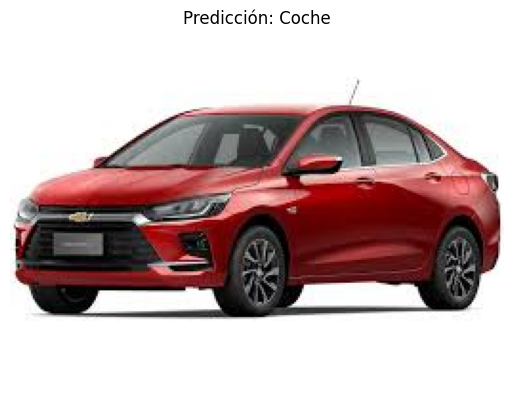

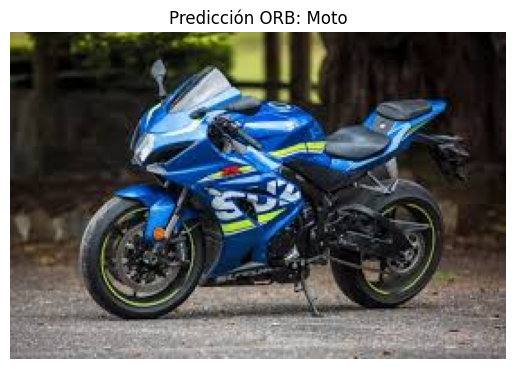

np.str_('Moto')

In [60]:
predict_image_sift("./content/imagen1.jpg")
predict_image_orb("./content/imagen3.jpg")